In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cv2

In [4]:
img = plt.imread('shivaji_maharaj.jpg')

In [5]:
imgGray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [66]:
smoothingMask =  np.ones((15,15))/225

In [67]:
imgBlurred = signal.convolve2d(imgGray, smoothingMask, boundary='symm', mode='same')

(1200, 1600)
(1200, 1600, 3)


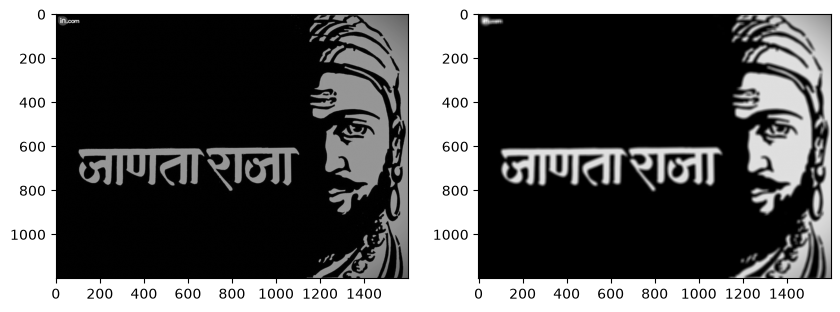

In [68]:
print(imgBlurred.shape)
print(img.shape)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,15))
ax1.imshow(imgGray, cmap='gray')
ax2.imshow(imgBlurred, cmap='gray')

In [23]:
xMask = np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]])
yMask = xMask.T.copy()

In [25]:
fx = signal.convolve2d(imgGray, xMask, boundary='symm', mode='same')
fy = signal.convolve2d(imgGray, yMask, boundary='symm', mode='same')

In [26]:
fx.shape

(1200, 1600)

In [27]:
imgGray.shape

(1200, 1600)

In [28]:
Gm = (fx**2 + fy**2)**0.5

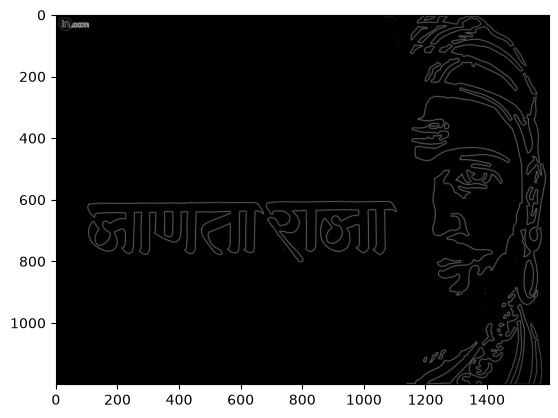

In [29]:
plt.imshow(Gm, cmap='gray')

[[0.         2.23606798 2.82842712 ... 0.         0.         0.        ]
 [0.         1.41421356 2.23606798 ... 0.         0.         0.        ]
 [3.         3.         3.         ... 1.41421356 0.         0.        ]
 ...
 [0.         0.         0.         ... 1.41421356 0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


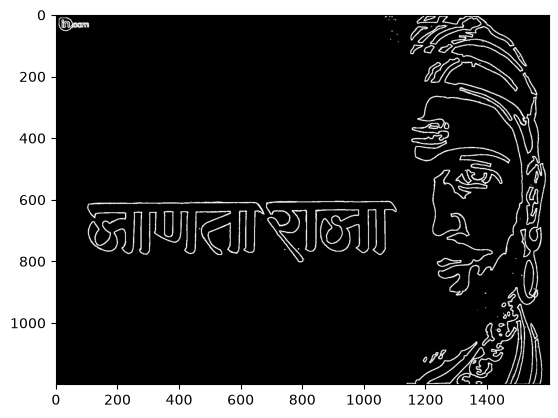

In [43]:
print(Gm)
plt.imshow(Gm>50, cmap='gray')

In [45]:
imgSharped = imgBlurred + 0.5*Gm

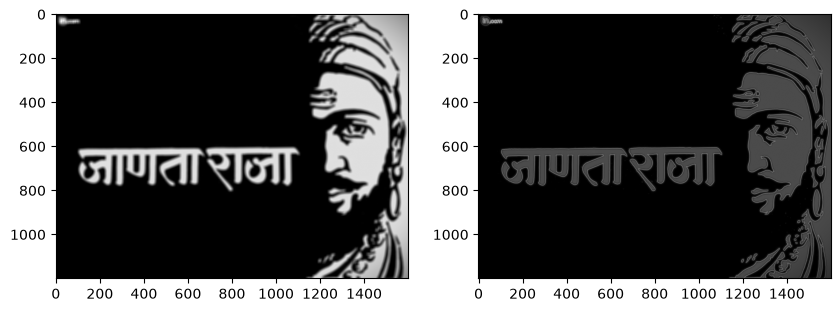

In [46]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,15))
ax1.imshow(imgBlurred, cmap='gray')
ax2.imshow(imgSharped, cmap='gray')